# Retail Intelligence: Analysing Sales Drivers and Predicting Weekly Store Sales Using Machine Learning

**IDRA Data Science & AI Capstone: Project 6**

This notebook analyses weekly store sales, performs data-quality checks and exploratory analysis, and compares regression models using a chronological train/test split. Interactive Plotly charts are used for exploration; report-ready static figures are generated separately.

## Mathematical foundation

**Mean**
\[
\bar{x}=\frac{1}{n}\sum_{i=1}^{n}x_i
\]

**Pearson correlation**
\[
r=\frac{\operatorname{Cov}(X,Y)}{\sigma_X\sigma_Y}
\]

**Linear regression**
\[
\hat y=\beta_0+\beta_1x_1+\cdots+\beta_px_p
\]

**Decision tree regression:** each terminal leaf predicts the mean target value of the observations reaching that leaf.

**Random forest**
\[
\hat y=\frac{1}{B}\sum_{b=1}^{B}\hat y^{(b)}
\]

**MAE**
\[
MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat y_i|
\]

**MSE**
\[
MSE=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2
\]

**RMSE**
\[
RMSE=\sqrt{MSE}
\]

**R²**
\[
R^2=1-\frac{\sum(y_i-\hat y_i)^2}{\sum(y_i-\bar y)^2}
\]

## Imports and paths

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Keep input/output paths portable across Windows, Jupyter and Colab.
cwd = Path.cwd()
candidates = [
    cwd / "P_6_Walmart.csv",
    cwd / "data" / "P_6_Walmart.csv",
    Path("/mnt/data/P_6_Walmart.csv"),
]
raw_path = next((p for p in candidates if p.exists()), None)
if raw_path is None:
    raise FileNotFoundError("Place P_6_Walmart.csv in the notebook folder or /mnt/data.")

output_dir = cwd / "Project6_outputs"
output_dir.mkdir(parents=True, exist_ok=True)

print("Input:", raw_path)
print("Output folder:", output_dir)

Input: C:\Users\Hp\IDRA Training 2026\capstone project\P_6_Walmart.csv
Output folder: C:\Users\Hp\IDRA Training 2026\capstone project\Project6_outputs


## Load and understand the dataset

In [2]:
df = pd.read_csv(raw_path)

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())
display(df.info())

Shape: 6,435 rows × 8 columns


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


None

In [3]:
summary = pd.DataFrame({
    "Column": df.columns,
    "Data type": df.dtypes.astype(str).values,
    "Missing values": df.isna().sum().values,
    "Unique values": df.nunique().values
})
display(summary)

,Column,Data type,Missing values,Unique values
0,Store,int64,0,45
1,Date,object,0,143
2,Weekly_Sales,float64,0,6435
3,Holiday_Flag,int64,0,2
4,Temperature,float64,0,3528
5,Fuel_Price,float64,0,892
6,CPI,float64,0,2145
7,Unemployment,float64,0,349


## Data cleaning and validation

In [4]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="raise")

quality = {
    "Missing values": int(df.isna().sum().sum()),
    "Duplicate rows": int(df.duplicated().sum()),
    "Duplicate Store-Date pairs": int(df.duplicated(["Store", "Date"]).sum()),
    "Non-positive Weekly_Sales": int((df["Weekly_Sales"] <= 0).sum()),
    "Invalid Holiday_Flag": int((~df["Holiday_Flag"].isin([0, 1])).sum()),
}
display(pd.DataFrame(quality.items(), columns=["Check", "Count"]))

,Check,Count
0,Missing values,0
1,Duplicate rows,0
2,Duplicate Store-Date pairs,0
3,Non-positive Weekly_Sales,0
4,Invalid Holiday_Flag,0


In [5]:
# Confirm the weekly structure.
unique_dates = np.sort(df["Date"].unique())
date_gaps = pd.Series(unique_dates).diff().dropna().dt.days
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("Unique stores:", df["Store"].nunique())
print("Unique dates:", df["Date"].nunique())
print("Weekly intervals not equal to 7 days:", int((date_gaps != 7).sum()))

Date range: 2010-02-05 to 2012-10-26
Unique stores: 45
Unique dates: 143
Weekly intervals not equal to 7 days: 0


## Descriptive statistics

In [6]:
numeric_cols = ["Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment"]
display(df[numeric_cols].describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
Weekly_Sales,6435.0,1046964.88,564366.62,209986.25,553350.10,960746.04,1420158.66,3818686.45
Temperature,6435.0,60.66,18.44,-2.06,47.46,62.67,74.94,100.14
Fuel_Price,6435.0,3.36,0.46,2.47,2.93,3.44,3.74,4.47
CPI,6435.0,171.58,39.36,126.06,131.74,182.62,212.74,227.23
Unemployment,6435.0,8.00,1.88,3.88,6.89,7.87,8.62,14.31


## Feature engineering

In [7]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

# TimeIndex and cyclical encodings represent temporal position and seasonality.
df["TimeIndex"] = (df["Date"] - df["Date"].min()).dt.days // 7
df["MonthSin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["MonthCos"] = np.cos(2 * np.pi * df["Month"] / 12)
df["WeekSin"] = np.sin(2 * np.pi * df["WeekOfYear"] / 52)
df["WeekCos"] = np.cos(2 * np.pi * df["WeekOfYear"] / 52)

print("Features added:", ["Year","Month","Quarter","WeekOfYear","TimeIndex",
                         "MonthSin","MonthCos","WeekSin","WeekCos"])

Features added: ['Year', 'Month', 'Quarter', 'WeekOfYear', 'TimeIndex', 'MonthSin', 'MonthCos', 'WeekSin', 'WeekCos']


## Holiday and store summaries

In [8]:
holiday_summary = (
    df.groupby("Holiday_Flag")["Weekly_Sales"]
      .agg(["count", "mean", "median", "std"])
      .rename(index={0: "Non-holiday", 1: "Holiday"})
)
display(holiday_summary.round(2))

store_summary = (
    df.groupby("Store")["Weekly_Sales"]
      .agg(["count", "mean", "median", "std"])
      .sort_values("mean", ascending=False)
)
display(store_summary.round(2))

,count,mean,median,std
Holiday_Flag,,,,
Non-holiday,5985,1041256.38,956211.20,558957.44
Holiday,450,1122887.89,1018538.04,627684.93


,count,mean,median,std
Store,,,,
20,143,2107676.87,2053165.41,275900.56
4,143,2094712.96,2073951.38,266201.44
14,143,2020978.40,2004330.30,317569.95
13,143,2003620.31,1958823.56,265507.00
2,143,1925751.34,1879107.31,237683.69
10,143,1899424.57,1827521.71,302262.06
27,143,1775216.20,1731935.43,239930.14
6,143,1564728.19,1524390.07,212525.86
1,143,1555264.40,1534849.64,155980.77


## Outlier screening

In [9]:
def iqr_flags(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    flags = (series < lower) | (series > upper)
    return q1, q3, iqr, lower, upper, int(flags.sum())

outlier_rows = []
for col in numeric_cols:
    q1, q3, iqr, lower, upper, count = iqr_flags(df[col])
    outlier_rows.append([col, q1, q3, iqr, lower, upper, count])

outlier_summary = pd.DataFrame(
    outlier_rows,
    columns=["Variable","Q1","Q3","IQR","Lower bound","Upper bound","IQR flags"]
)
display(outlier_summary.round(2))

# IQR flags are screening results; they are not automatically erroneous observations.

,Variable,Q1,Q3,IQR,Lower bound,Upper bound,IQR flags
0,Weekly_Sales,553350.10,1420158.66,866808.56,-746862.73,2720371.49,34
1,Temperature,47.46,74.94,27.48,6.24,116.16,3
2,Fuel_Price,2.93,3.74,0.80,1.73,4.94,0
3,CPI,131.74,212.74,81.01,10.22,334.26,0
4,Unemployment,6.89,8.62,1.73,4.29,11.22,481


## Exploratory analysis: interactive plots

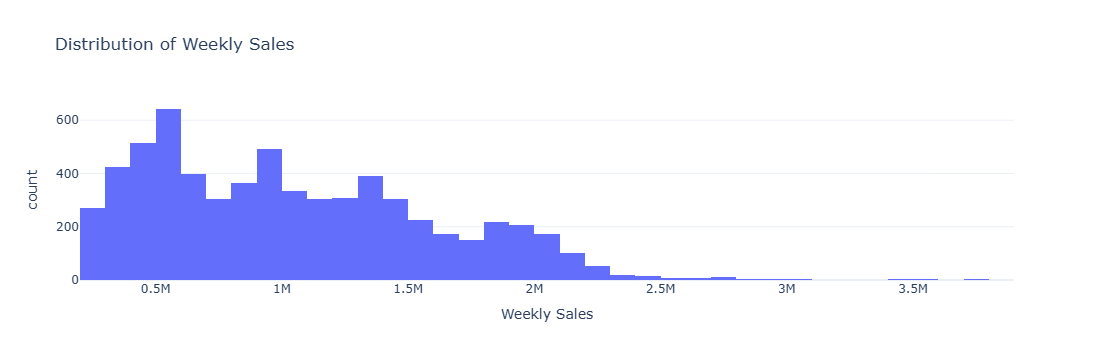

In [10]:
# Figure 1 — Distribution of weekly sales
fig = px.histogram(df, x="Weekly_Sales", nbins=50,
                   title="Distribution of Weekly Sales",
                   labels={"Weekly_Sales":"Weekly Sales"})
fig.update_layout(template="plotly_white")
fig.show()

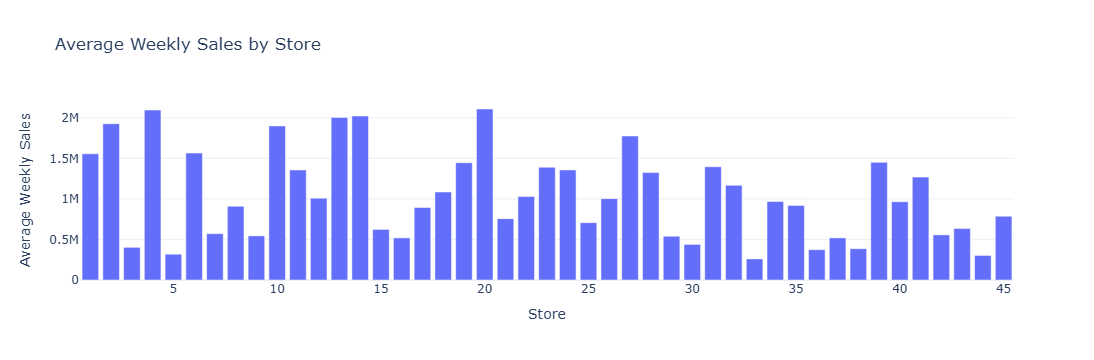

In [11]:
# Figure 2 — Average weekly sales by store
plot_store = store_summary.reset_index()
fig = px.bar(plot_store, x="Store", y="mean",
             title="Average Weekly Sales by Store",
             labels={"mean":"Average Weekly Sales"})
fig.update_layout(template="plotly_white")
fig.show()

In [12]:
# Figure 3 — Aggregate weekly sales over time
weekly_total = df.groupby("Date", as_index=False)["Weekly_Sales"].sum()
fig = px.line(weekly_total, x="Date", y="Weekly_Sales",
              title="Aggregate Weekly Sales Over Time",
              labels={"Weekly_Sales":"Total Weekly Sales"})
fig.update_layout(template="plotly_white")
fig.show()

In [13]:
# Figure 4 — Unemployment and weekly sales
fig = px.scatter(df, x="Unemployment", y="Weekly_Sales",
                 opacity=0.45, trendline="ols",
                 title="Unemployment and Weekly Sales",
                 labels={"Weekly_Sales":"Weekly Sales"})
fig.update_layout(template="plotly_white")
fig.show()

In [14]:
# Figure 5 — Correlation matrix (Store ID excluded because it is categorical)
corr_cols = ["Weekly_Sales","Holiday_Flag","Temperature","Fuel_Price","CPI","Unemployment"]
corr = df[corr_cols].corr()
fig = px.imshow(corr, text_auto=".2f", aspect="auto",
                title="Correlation Matrix")
fig.update_layout(template="plotly_white")
fig.show()

In [15]:
# Figure 6 — Holiday comparison
holiday_plot = (
    df.assign(Holiday=df["Holiday_Flag"].map({0:"Non-holiday",1:"Holiday"}))
      .groupby("Holiday", as_index=False)["Weekly_Sales"].mean()
)
fig = px.bar(holiday_plot, x="Holiday", y="Weekly_Sales",
             title="Average Weekly Sales: Holiday vs Non-holiday",
             labels={"Weekly_Sales":"Average Weekly Sales"})
fig.update_layout(template="plotly_white")
fig.show()

In [16]:
# Figure 7 — Monthly sales pattern
monthly = df.groupby("Month", as_index=False)["Weekly_Sales"].mean()
fig = px.line(monthly, x="Month", y="Weekly_Sales", markers=True,
              title="Average Weekly Sales by Month",
              labels={"Weekly_Sales":"Average Weekly Sales"})
fig.update_layout(template="plotly_white")
fig.show()

## Machine learning setup

In [17]:
target = "Weekly_Sales"
features = [
    "Store","Holiday_Flag","Temperature","Fuel_Price","CPI","Unemployment",
    "Year","Month","Quarter","WeekOfYear","TimeIndex",
    "MonthSin","MonthCos","WeekSin","WeekCos"
]

categorical = ["Store","Year","Month","Quarter"]
numerical = [c for c in features if c not in categorical]

# Split by unique dates so every store's observations follow the same time boundary.
dates = np.sort(df["Date"].unique())
cutoff_date = dates[int(len(dates) * 0.80)]

train_df = df[df["Date"] < cutoff_date].copy()
test_df = df[df["Date"] >= cutoff_date].copy()

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

print("Train:", train_df["Date"].min().date(), "to", train_df["Date"].max().date(),
      "| rows:", len(train_df))
print("Test :", test_df["Date"].min().date(), "to", test_df["Date"].max().date(),
      "| rows:", len(test_df))

Train: 2010-02-05 to 2012-04-06 | rows: 5130
Test : 2012-04-13 to 2012-10-26 | rows: 1305


In [18]:
# Categorical variables are one-hot encoded. Scaling is applied only to numerical inputs
# for Linear Regression; tree models do not require numerical scaling.
preprocess_lr = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical),
    ("numerical", StandardScaler(), numerical)
])

preprocess_tree = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical),
    ("numerical", "passthrough", numerical)
])

## Linear Regression

\[
\hat y=\beta_0+\beta_1x_1+\cdots+\beta_px_p
\]

The model estimates coefficients that minimise the sum of squared residuals.

In [19]:
linear_model = Pipeline([
    ("preprocess", preprocess_lr),
    ("model", LinearRegression())
])
linear_model.fit(X_train, y_train)

lr_train_pred = linear_model.predict(X_train)
lr_test_pred = linear_model.predict(X_test)

## Decision Tree Regression

A decision tree recursively partitions the feature space. A terminal leaf predicts the mean weekly sales of the training observations assigned to that leaf.

In [20]:
tree_model = Pipeline([
    ("preprocess", preprocess_tree),
    ("model", DecisionTreeRegressor(
        max_depth=20,
        min_samples_leaf=2,
        random_state=42
    ))
])
tree_model.fit(X_train, y_train)

tree_train_pred = tree_model.predict(X_train)
tree_test_pred = tree_model.predict(X_test)

## Random Forest Regression

\[
\hat y=\frac{1}{B}\sum_{b=1}^{B}\hat y^{(b)}
\]

A random forest averages predictions from multiple decision trees.

In [21]:
rf_model = Pipeline([
    ("preprocess", preprocess_tree),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])
rf_model.fit(X_train, y_train)

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

## Evaluation

**MAE** is the average absolute prediction error and remains in sales units.

**MSE** is the average squared prediction error. Because errors are squared, its numerical magnitude is much larger and its units are sales².

**RMSE** is the square root of MSE, returning the metric to sales units.

**R²** measures the proportion of target variance explained relative to a mean-prediction baseline. It is not a percentage accuracy measure.

In [22]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }

models_pred = {
    "Linear Regression": (lr_train_pred, lr_test_pred),
    "Decision Tree": (tree_train_pred, tree_test_pred),
    "Random Forest": (rf_train_pred, rf_test_pred)
}

rows = []
for name, (train_pred, test_pred) in models_pred.items():
    tr = regression_metrics(y_train, train_pred)
    te = regression_metrics(y_test, test_pred)
    rows.extend([
        [name, "Train", tr["MAE"], tr["MSE"], tr["RMSE"], tr["R2"]],
        [name, "Test", te["MAE"], te["MSE"], te["RMSE"], te["R2"]]
    ])

results_df = pd.DataFrame(rows, columns=["Model","Split","MAE","MSE","RMSE","R2"])
display(results_df.round(2))

,Model,Split,MAE,MSE,RMSE,R2
0,Linear Regression,Train,90208.88,2.201202e+10,148364.47,0.93
1,Linear Regression,Test,69599.74,1.018868e+10,100939.01,0.96
2,Decision Tree,Train,106886.91,2.968275e+10,172286.83,0.91
3,Decision Tree,Test,138300.88,3.401159e+10,184422.31,0.88
4,Random Forest,Train,98904.00,2.334489e+10,152790.36,0.93
5,Random Forest,Test,110582.21,2.255581e+10,150185.93,0.92


## Baseline comparison

In [23]:
baseline_prediction = np.repeat(y_train.mean(), len(y_test))
baseline = regression_metrics(y_test, baseline_prediction)

baseline_row = pd.DataFrame([[
    "Mean Baseline", "Test", baseline["MAE"], baseline["MSE"],
    baseline["RMSE"], baseline["R2"]
]], columns=results_df.columns)

display(pd.concat([baseline_row, results_df[results_df["Split"]=="Test"]], ignore_index=True).round(2))

,Model,Split,MAE,MSE,RMSE,R2
0,Mean Baseline,Test,454692.95,2.848471e+11,533710.71,-0.00
1,Linear Regression,Test,69599.74,1.018868e+10,100939.01,0.96
2,Decision Tree,Test,138300.88,3.401159e+10,184422.31,0.88
3,Random Forest,Test,110582.21,2.255581e+10,150185.93,0.92


## Actual vs predicted and residuals — Linear Regression

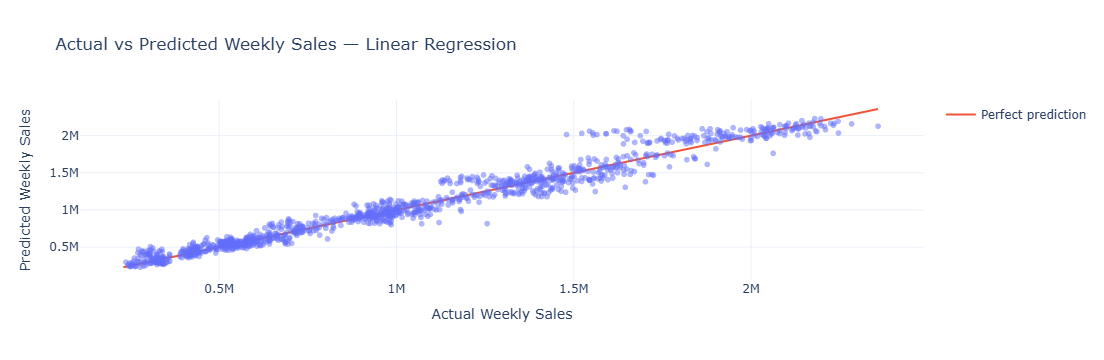

In [24]:
actual_pred = test_df[["Store","Date","Weekly_Sales"]].copy()
actual_pred["Predicted_Sales"] = lr_test_pred
actual_pred["Residual"] = actual_pred["Weekly_Sales"] - actual_pred["Predicted_Sales"]
actual_pred["Absolute_Error"] = actual_pred["Residual"].abs()

fig = px.scatter(actual_pred, x="Weekly_Sales", y="Predicted_Sales",
                 hover_data=["Store","Date"],
                 opacity=0.5,
                 title="Actual vs Predicted Weekly Sales — Linear Regression",
                 labels={"Weekly_Sales":"Actual Weekly Sales",
                         "Predicted_Sales":"Predicted Weekly Sales"})
lo = min(actual_pred["Weekly_Sales"].min(), actual_pred["Predicted_Sales"].min())
hi = max(actual_pred["Weekly_Sales"].max(), actual_pred["Predicted_Sales"].max())
fig.add_trace(go.Scatter(x=[lo,hi], y=[lo,hi], mode="lines",
                         name="Perfect prediction"))
fig.update_layout(template="plotly_white")
fig.show()

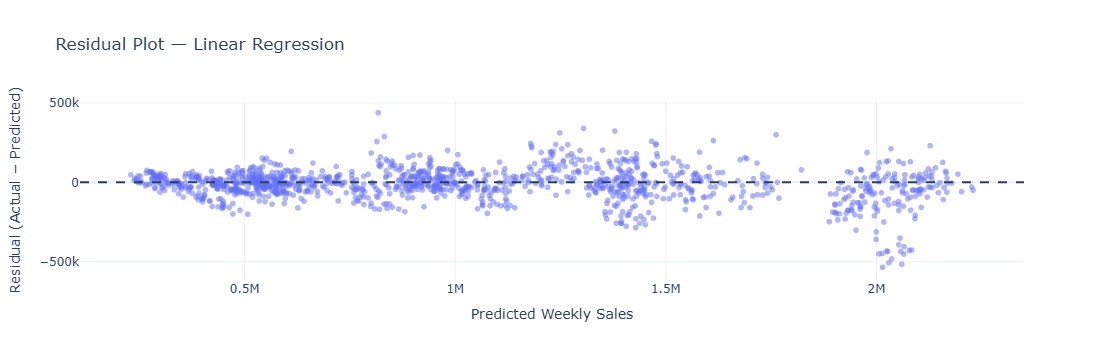

Residual mean: -11591.77
Residual median: -6108.43
Residual standard deviation: 100309.65


In [25]:
fig = px.scatter(actual_pred, x="Predicted_Sales", y="Residual",
                 hover_data=["Store","Date"],
                 opacity=0.5,
                 title="Residual Plot — Linear Regression",
                 labels={"Predicted_Sales":"Predicted Weekly Sales",
                         "Residual":"Residual (Actual − Predicted)"})
fig.add_hline(y=0, line_dash="dash", name="Zero residual")
fig.update_layout(template="plotly_white")
fig.show()

print("Residual mean:", round(actual_pred["Residual"].mean(), 2))
print("Residual median:", round(actual_pred["Residual"].median(), 2))
print("Residual standard deviation:", round(actual_pred["Residual"].std(), 2))

## Store-wise test error

,Store,MAE,RMSE,Mean_Actual
13,14,307907.29,347876.64,1744444.27
27,28,183714.19,200701.69,1243243.73
9,10,160118.56,173633.33,1778492.69
40,41,136998.57,152410.90,1370551.66
35,36,123902.90,129091.64,303099.35
16,17,113437.93,144733.73,959939.34
38,39,109964.48,130101.00,1564834.86
20,21,105061.14,116108.90,695918.02
23,24,101571.38,130970.39,1363154.52
11,12,99254.24,111822.42,986908.06


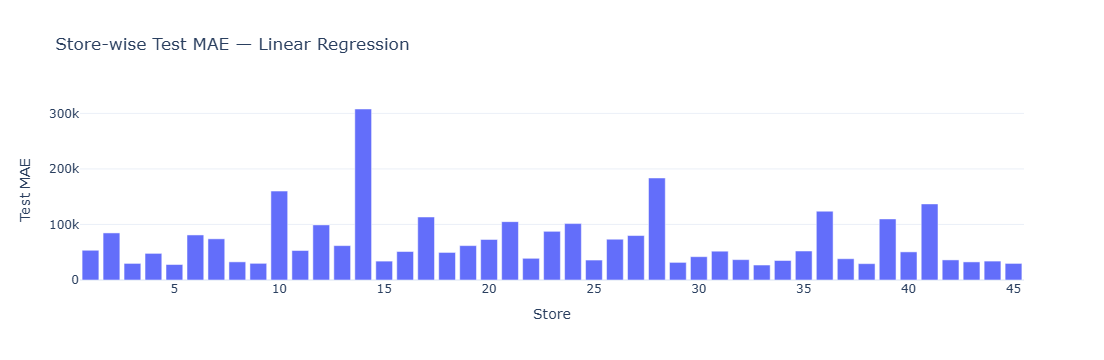

In [26]:
store_error = (
    actual_pred.groupby("Store")
    .agg(
        MAE=("Absolute_Error","mean"),
        RMSE=("Residual", lambda x: np.sqrt(np.mean(x**2))),
        Mean_Actual=("Weekly_Sales","mean")
    )
    .reset_index()
)
display(store_error.sort_values("MAE", ascending=False).round(2))

fig = px.bar(store_error.sort_values("MAE", ascending=False),
             x="Store", y="MAE",
             title="Store-wise Test MAE — Linear Regression",
             labels={"MAE":"Test MAE"})
fig.update_layout(template="plotly_white")
fig.show()

## Effect of the Store feature

In [27]:
# This diagnostic tests how much predictive information is carried by store identity.
features_no_store = [c for c in features if c != "Store"]
categorical_no_store = [c for c in categorical if c != "Store"]
numerical_no_store = [c for c in features_no_store if c not in categorical_no_store]

prep_no_store = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_no_store),
    ("numerical", StandardScaler(), numerical_no_store)
])

lr_no_store = Pipeline([
    ("preprocess", prep_no_store),
    ("model", LinearRegression())
])
lr_no_store.fit(train_df[features_no_store], y_train)
no_store_pred = lr_no_store.predict(test_df[features_no_store])
no_store_metrics = regression_metrics(y_test, no_store_pred)

print("Linear Regression without Store")
for k,v in no_store_metrics.items():
    print(f"{k}: {v:,.2f}")

Linear Regression without Store
MAE: 447,963.61
MSE: 279,869,084,699.64
RMSE: 529,026.54
R2: 0.02


## Leakage-safe historical-sales forecasting

Previous sales can be useful for forecasting. The lag features below use only information available **before** the current week:

\[
Lag_1(t)=Sales(t-1)
\]

\[
Lag_4(t)=Sales(t-4)
\]

\[
RollingMean_4(t)=\frac{Sales(t-1)+Sales(t-2)+Sales(t-3)+Sales(t-4)}{4}
\]

`shift(1)` is applied before the rolling calculation so the current target is never used to construct its own predictors.

In [28]:
lag_df = df.sort_values(["Store","Date"]).copy()

lag_df["Lag_1_Sales"] = lag_df.groupby("Store")["Weekly_Sales"].shift(1)
lag_df["Lag_4_Sales"] = lag_df.groupby("Store")["Weekly_Sales"].shift(4)
lag_df["Rolling_Mean_4"] = (
    lag_df.groupby("Store")["Weekly_Sales"]
          .transform(lambda s: s.shift(1).rolling(4, min_periods=4).mean())
)

print(lag_df[["Lag_1_Sales","Lag_4_Sales","Rolling_Mean_4"]].isna().sum())

Lag_1_Sales        45
Lag_4_Sales       180
Rolling_Mean_4    180
dtype: int64


In [29]:
lag_model_df = lag_df.dropna(
    subset=["Lag_1_Sales","Lag_4_Sales","Rolling_Mean_4"]
).copy()

lag_dates = np.sort(lag_model_df["Date"].unique())
lag_cutoff = lag_dates[int(len(lag_dates) * 0.80)]

lag_train = lag_model_df[lag_model_df["Date"] < lag_cutoff]
lag_test = lag_model_df[lag_model_df["Date"] >= lag_cutoff]

lag_features = features + ["Lag_1_Sales","Lag_4_Sales","Rolling_Mean_4"]
lag_numerical = [c for c in lag_features if c not in categorical]

lag_preprocess = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical),
    ("numerical", StandardScaler(), lag_numerical)
])

lag_model = Pipeline([
    ("preprocess", lag_preprocess),
    ("model", LinearRegression())
])
lag_model.fit(lag_train[lag_features], lag_train[target])

lag_train_pred = lag_model.predict(lag_train[lag_features])
lag_test_pred = lag_model.predict(lag_test[lag_features])

lag_train_metrics = regression_metrics(lag_train[target], lag_train_pred)
lag_test_metrics = regression_metrics(lag_test[target], lag_test_pred)

print("Historical-sales model — Train:", {k: round(v,2) for k,v in lag_train_metrics.items()})
print("Historical-sales model — Test :", {k: round(v,2) for k,v in lag_test_metrics.items()})

Historical-sales model — Train: {'MAE': 83057.99, 'MSE': 19560378494.21, 'RMSE': np.float64(139858.42), 'R2': 0.94}
Historical-sales model — Test : {'MAE': 55854.25, 'MSE': 6003988431.52, 'RMSE': np.float64(77485.41), 'R2': 0.98}


## Random Forest feature importance

In [30]:
# Aggregate one-hot encoded Store/Year/Month/Quarter importance back to original variables.
rf_pre = rf_model.named_steps["preprocess"]
rf_est = rf_model.named_steps["model"]

encoded_names = list(rf_pre.named_transformers_["categorical"].get_feature_names_out(categorical))
all_feature_names = encoded_names + numerical
importance = pd.Series(rf_est.feature_importances_, index=all_feature_names)

def original_feature(name):
    for c in categorical:
        prefix = c + "_"
        if name.startswith(prefix):
            return c
    return name

importance_df = (
    importance.rename("Importance")
              .reset_index().rename(columns={"index":"Encoded_Feature"})
)
importance_df["Feature"] = importance_df["Encoded_Feature"].map(original_feature)

rf_aggregated = (
    importance_df.groupby("Feature", as_index=False)["Importance"]
                 .sum()
                 .sort_values("Importance", ascending=False)
)
rf_aggregated["Importance_%"] = 100 * rf_aggregated["Importance"]
display(rf_aggregated.round(4).head(15))

fig = px.bar(rf_aggregated.head(10).sort_values("Importance_%"),
             x="Importance_%", y="Feature", orientation="h",
             title="Top Predictive Features — Random Forest",
             labels={"Importance_%":"Aggregated Feature Importance (%)"})
fig.update_layout(template="plotly_white")
fig.show()

,Feature,Importance,Importance_%
7,Store,0.8992,89.9173
0,CPI,0.0392,3.9194
12,WeekOfYear,0.0364,3.6415
8,Temperature,0.0058,0.5806
11,WeekCos,0.0044,0.4356
13,WeekSin,0.0039,0.3869
9,TimeIndex,0.0030,0.2958
1,Fuel_Price,0.0023,0.2345
3,Month,0.0022,0.2178
4,MonthCos,0.0009,0.0922


## Final results and evidence

In [31]:
test_results = results_df[results_df["Split"]=="Test"].copy()

final_comparison = pd.concat([
    baseline_row,
    test_results,
    pd.DataFrame([[
        "Historical-sales Linear Regression", "Test",
        lag_test_metrics["MAE"], lag_test_metrics["MSE"],
        lag_test_metrics["RMSE"], lag_test_metrics["R2"]
    ]], columns=results_df.columns)
], ignore_index=True)

display(final_comparison.round(2))

best_by_mae = final_comparison.loc[final_comparison["MAE"].idxmin()]
print(f"Lowest test MAE in evaluated models: {best_by_mae['Model']} ({best_by_mae['MAE']:,.2f})")

print("\nKey dataset findings:")
print("• Rows:", len(df))
print("• Columns:", df.shape[1])
print("• Stores:", df["Store"].nunique())
print("• Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("• Mean Weekly Sales:", round(df["Weekly_Sales"].mean(), 2))
print("• Holiday mean:", round(df.loc[df.Holiday_Flag==1, "Weekly_Sales"].mean(), 2))
print("• Non-holiday mean:", round(df.loc[df.Holiday_Flag==0, "Weekly_Sales"].mean(), 2))

,Model,Split,MAE,MSE,RMSE,R2
0,Mean Baseline,Test,454692.95,2.848471e+11,533710.71,-0.00
1,Linear Regression,Test,69599.74,1.018868e+10,100939.01,0.96
2,Decision Tree,Test,138300.88,3.401159e+10,184422.31,0.88
3,Random Forest,Test,110582.21,2.255581e+10,150185.93,0.92
4,Historical-sales Linear Regression,Test,55854.25,6.003988e+09,77485.41,0.98


Lowest test MAE in evaluated models: Historical-sales Linear Regression (55,854.25)

Key dataset findings:
• Rows: 6435
• Columns: 17
• Stores: 45
• Date range: 2010-02-05 to 2012-10-26
• Mean Weekly Sales: 1046964.88
• Holiday mean: 1122887.89
• Non-holiday mean: 1041256.38


## Export final supporting files

In [32]:
# Use a project-local output folder instead of /mnt/data, which is not a valid Windows path.
df.to_csv(output_dir / "P_6_Walmart_Cleaned_Featured.csv", index=False)
results_df.to_csv(output_dir / "Project6_Regression_Model_Results.csv", index=False)
final_comparison.to_csv(output_dir / "Project6_Final_Model_Comparison.csv", index=False)
actual_pred.to_csv(output_dir / "Project6_Actual_vs_Predicted.csv", index=False)
store_error.to_csv(output_dir / "Project6_Store_Wise_Test_Errors.csv", index=False)
rf_aggregated.to_csv(output_dir / "Project6_RF_Aggregated_Feature_Importance.csv", index=False)
outlier_summary.to_csv(output_dir / "Project6_Outlier_Summary.csv", index=False)

print("Export complete:")
for p in sorted(output_dir.glob("*.csv")):
    print(" -", p.name)

Export complete:
 - P_6_Walmart_Cleaned_Featured.csv
 - Project6_Actual_vs_Predicted.csv
 - Project6_Final_Model_Comparison.csv
 - Project6_Outlier_Summary.csv
 - Project6_Regression_Model_Results.csv
 - Project6_RF_Aggregated_Feature_Importance.csv
 - Project6_Store_Wise_Test_Errors.csv


## Findings for the report

- Weekly sales vary substantially across stores, indicating strong store-level heterogeneity.
- Holiday-flagged weeks have a higher observed mean weekly sales than non-holiday weeks; this is an association, not a causal estimate.
- The available economic and environmental variables show weak raw pairwise correlations with weekly sales.
- Store identity carries substantial predictive information; removing it causes a large deterioration in Linear Regression test performance.
- Under the chronological holdout, the benchmark Linear Regression, Decision Tree and Random Forest provide different levels of generalisation. The historical-sales Linear Regression experiment further improves test error by using only prior weeks' sales.
- The results should be interpreted as prediction performance on this historical dataset, not as causal evidence about sales drivers.